Dynamic movies: average gaze position

Loads dynamic (`task-OrientationImageryDynamic`) eyetracking for participants `S01-S20` and computes:

1. Overall average gaze position for each movie condition.
2. Time-resolved gaze position over the course of each movie (averaged across participants).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

import eyetracking_preprocessing

BIDS_ROOT = Path('/Users/sm6511/Desktop/NIH_Experiment/Bids')
SUBJECTS = [f'S{i:02d}' for i in range(1, 21)]

# Keep consistent with your previous preprocessing setup
SFREQ = 1200
EVENT_IDS = list(range(1, 18))
TMIN, TMAX = -.2, 3.5

# Movie analysis window within each epoch (seconds)
MOVIE_TMIN, MOVIE_TMAX = 0.0, 3.2

print('BIDS root:', BIDS_ROOT)
print('Subjects:', SUBJECTS)

BIDS root: /Users/sm6511/Desktop/NIH_Experiment/Bids
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20']


In [2]:
def get_dynamic_ds_paths(bids_root: Path, subj: str):
    meg_dir = bids_root / f'sub-{subj}' / 'ses-1' / 'meg'
    pattern = f'sub-{subj}_ses-1_task-OrientationImageryDynamic_run-*_meg.ds'
    return sorted(meg_dir.glob(pattern))


def events_file_from_ds(ds_path: Path):
    base = ds_path.name.replace('_meg.ds', '')
    return ds_path.parent / f'{base}_events.tsv'


def parse_condition(trial_type):
    if pd.isna(trial_type):
        return 'unknown'
    parts = str(trial_type).split('/')
    if len(parts) >= 3:
        return parts[2]
    return parts[-1] if parts else 'unknown'


def load_run_epochs(ds_path: Path):
    eyes = eyetracking_preprocessing.process_run(str(ds_path))
    eye_df = eyes[['x_deg', 'y_deg', 'pupil']].copy()

    info = mne.create_info(['x_deg', 'y_deg', 'pupil'], sfreq=SFREQ)
    raw_eye = mne.io.RawArray(eye_df.to_numpy().T, info, first_samp=0)

    raw_meg = mne.io.read_raw_ctf(str(ds_path), preload=False, system_clock='ignore', clean_names=True)
    events, _ = mne.events_from_annotations(raw_meg)
    events = events[np.isin(events[:, 2], EVENT_IDS)]

    metadata = None
    events_tsv = events_file_from_ds(ds_path)
    if events_tsv.exists():
        metadata = pd.read_csv(events_tsv, sep='\t')
        if len(metadata) >= len(events):
            metadata = metadata.iloc[:len(events)].reset_index(drop=True)
        else:
            events = events[:len(metadata)]
            metadata = metadata.reset_index(drop=True)

        if 'trial_type' in metadata.columns:
            metadata['condition'] = metadata['trial_type'].apply(parse_condition)
        else:
            metadata['condition'] = 'unknown'

    epochs = mne.Epochs(
        raw_eye,
        events,
        event_id=EVENT_IDS,
        tmin=TMIN,
        tmax=TMAX,
        baseline=(TMIN, 0.0),
        metadata=metadata,
        preload=True,
        reject_by_annotation=False,
    )
    return epochs

In [3]:
# Load all dynamic data and build trial-level + time-resolved tables
trial_rows = []
timecourse_rows = []
missing_subjects = []

for subj in SUBJECTS:
    ds_paths = get_dynamic_ds_paths(BIDS_ROOT, subj)
    if len(ds_paths) == 0:
        missing_subjects.append(subj)
        continue

    for run_idx, ds_path in enumerate(ds_paths, start=1):
        try:
            epochs = load_run_epochs(ds_path)
        except Exception as exc:
            print(f'[WARN] {subj} run-{run_idx:02d} failed: {exc}')
            continue

        movie_epochs = epochs.copy().crop(MOVIE_TMIN, MOVIE_TMAX)
        times = movie_epochs.times
        x = movie_epochs.get_data(picks='x_deg')  # (n_trials, 1, n_times)
        y = movie_epochs.get_data(picks='y_deg')

        x = np.squeeze(x, axis=1)
        y = np.squeeze(y, axis=1)

        if epochs.metadata is not None and 'condition' in epochs.metadata.columns:
            conds = epochs.metadata['condition'].astype(str).to_list()
        else:
            conds = ['unknown'] * len(x)

        # (a) trial-level overall mean per movie
        x_trial_mean = np.nanmean(x, axis=1)
        y_trial_mean = np.nanmean(y, axis=1)

        for i in range(len(x_trial_mean)):
            trial_rows.append(
                {
                    'subject': subj,
                    'run': run_idx,
                    'condition': conds[i],
                    'x_mean_deg': x_trial_mean[i],
                    'y_mean_deg': y_trial_mean[i],
                }
            )

        # (b) subject-level condition timecourse
        for cond in sorted(set(conds)):
            idx = np.array([c == cond for c in conds])
            if not np.any(idx):
                continue

            cond_x_tc = np.nanmean(x[idx], axis=0)
            cond_y_tc = np.nanmean(y[idx], axis=0)

            for t_i, t in enumerate(times):
                timecourse_rows.append(
                    {
                        'subject': subj,
                        'condition': cond,
                        'time_s': float(t),
                        'x_deg': float(cond_x_tc[t_i]),
                        'y_deg': float(cond_y_tc[t_i]),
                    }
                )

trial_df = pd.DataFrame(trial_rows)
timecourse_df = pd.DataFrame(timecourse_rows)

print('Trial rows:', len(trial_df))
print('Timecourse rows:', len(timecourse_df))
print('Subjects with no dynamic runs found:', missing_subjects)
trial_df.head()

loading file /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_run-01_meg.ds
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_run-01_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       3.71   71.61    0.00 mm <->    3.71   71.61    0.00 mm (orig :  -41.09   60.20 -249.13 mm) diff =    0.000 mm
      -3.71  -71.61    0.00 mm <->   -3.71  -71.61    0.00 mm (orig :   56.21  -45.16 -250.58 mm) diff =    0.000 mm
      89.99    0.00    0.00 mm <->   89.99    0.00    0.00 mm (orig :   69.07   70.39 -230.81 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    Measurement info composed.
Finding samples for /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/

/Users/sm6511/Desktop/Orientation-Imagery/AnalysisScripts/Eyetracking/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.00032981671392414384
removed 2737 samples
removed 668 samples
removed 9 samples
removed 2 samples
removed 2 samples
Creating RawArray with float64 data, n_channels=3, n_times=595520
    Range : 0 ... 595519 =      0.000 ...   496.266 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_run-01_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       3.71   71.61    0.00 mm <->    3.71   71.61    0.00 mm (orig :  -41.09   60.20 -249.13 mm) diff =    0.000 mm
      -3.71  -71.61    0.00 mm <->   -3.71  -71.61    0.00 mm (orig :   56.21  -45.16 -250.58 mm) diff =    0.000 mm
      89.99    0.00    0.00 mm <->   89.99    0.00    0.00 mm (orig :   69.07   70.39 -230.81 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations fo

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_87079/4100096703.py:33: RuntimeWarning: Mean of empty slice
  x_trial_mean = np.nanmean(x, axis=1)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_87079/4100096703.py:34: RuntimeWarning: Mean of empty slice
  y_trial_mean = np.nanmean(y, axis=1)
/Users/sm6511/Desktop/Orientation-Imagery/AnalysisScripts/Eyetracking/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.0003732461482373357
removed 7282 samples
removed 1062 samples
removed 168 samples
removed 112 samples
removed 79 samples
Creating RawArray with float64 data, n_channels=3, n_times=566480
    Range : 0 ... 566479 =      0.000 ...   472.066 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_run-02_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       4.05   71.53    0.00 mm <->    4.05   71.53   -0.00 mm (orig :  -41.00   60.12 -250.02 mm) diff =    0.000 mm
      -4.05  -71.53    0.00 mm <->   -4.05  -71.53   -0.00 mm (orig :   56.27  -45.10 -250.65 mm) diff =    0.000 mm
      90.12    0.00    0.00 mm <->   90.12   -0.00    0.00 mm (orig :   68.62   70.71 -230.12 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locatio

...

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_87079/4100096703.py:33: RuntimeWarning: Mean of empty slice
  x_trial_mean = np.nanmean(x, axis=1)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_87079/4100096703.py:34: RuntimeWarning: Mean of empty slice
  y_trial_mean = np.nanmean(y, axis=1)


threshold: 0.06289576459755604
removed 18567 samples
removed 566 samples
removed 2938 samples
removed 2386 samples
removed 1789 samples
removed 1785 samples
Creating RawArray with float64 data, n_channels=3, n_times=560280
    Range : 0 ... 560279 =      0.000 ...   466.899 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S19/ses-1/meg/sub-S19_ses-1_task-OrientationImageryDynamic_run-04_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       1.14   75.87    0.00 mm <->    1.14   75.87   -0.00 mm (orig :  -40.27   65.78 -270.12 mm) diff =    0.000 mm
      -1.14  -75.87    0.00 mm <->   -1.14  -75.87   -0.00 mm (orig :   59.41  -48.64 -268.18 mm) diff =    0.000 mm
      84.15    0.00    0.00 mm <->   84.15   -0.00    0.00 mm (orig :   71.43   63.90 -283.06 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    De

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_87079/4100096703.py:33: RuntimeWarning: Mean of empty slice
  x_trial_mean = np.nanmean(x, axis=1)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_87079/4100096703.py:34: RuntimeWarning: Mean of empty slice
  y_trial_mean = np.nanmean(y, axis=1)


threshold: 0.04476542584906932
removed 342 samples
removed 0 samples
removed 235 samples
removed 821 samples
removed 578 samples
removed 875 samples
Creating RawArray with float64 data, n_channels=3, n_times=554520
    Range : 0 ... 554519 =      0.000 ...   462.099 secs
Ready.
ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S20/ses-1/meg/sub-S20_ses-1_task-OrientationImageryDynamic_run-01_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
      -4.72   70.32    0.00 mm <->   -4.72   70.32    0.00 mm (orig :  -53.06   48.95 -245.11 mm) diff =    0.000 mm
       4.72  -70.32    0.00 mm <->    4.72  -70.32    0.00 mm (orig :   43.62  -52.97 -256.67 mm) diff =    0.000 mm
      90.44    0.00    0.00 mm <->   90.44    0.00    0.00 mm (orig :   65.06   55.45 -247.80 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coo

,subject,run,condition,x_mean_deg,y_mean_deg
0,S01,1,0022_Left,0.000041,-0.000007
1,S01,1,0022_Right,0.000039,-0.000007
2,S01,1,0112_Left,0.000122,-0.000001
3,S01,1,0157_Right,0.000055,0.000015
4,S01,1,0067_Left,0.000035,0.000058


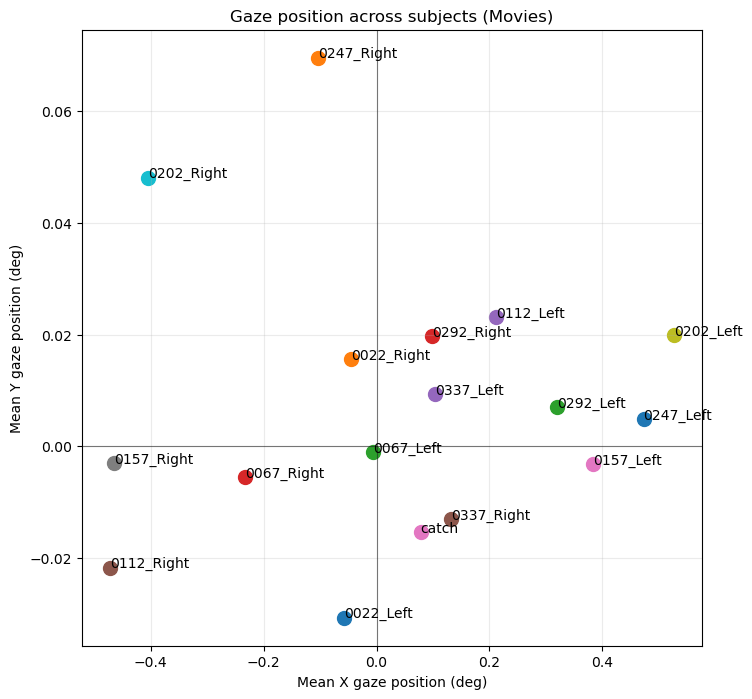

,condition,x_mean_deg,y_mean_deg
0,0022_Left,-0.058293,-0.030727
1,0022_Right,-0.044519,0.015648
2,0067_Left,-0.005993,-0.001105
3,0067_Right,-0.232537,-0.005555
4,0112_Left,0.210985,0.023078
5,0112_Right,-0.472138,-0.021770
6,0157_Left,0.382886,-0.003147
7,0157_Right,-0.465607,-0.002967
8,0202_Left,0.526480,0.019948
9,0202_Right,-0.404678,0.048131


In [6]:
if trial_df.empty:
    raise RuntimeError('No dynamic data loaded. Check BIDS_ROOT and file naming.')

# (a) Overall average gaze position per movie condition
overall = (
    trial_df.groupby('condition')[['x_mean_deg', 'y_mean_deg']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 8))
for _, row in overall.iterrows():
    plt.scatter(row['x_mean_deg'], row['y_mean_deg'], s=100)
    plt.text(row['x_mean_deg'], row['y_mean_deg'], str(row['condition']))

plt.axhline(0, color='k', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='k', linewidth=0.8, alpha=0.5)
plt.xlabel('Mean X gaze position (deg)')
plt.ylabel('Mean Y gaze position (deg)')
plt.title('Gaze position across subjects (Movies)')
plt.grid(alpha=0.25)
plt.show()

overall.sort_values('condition')

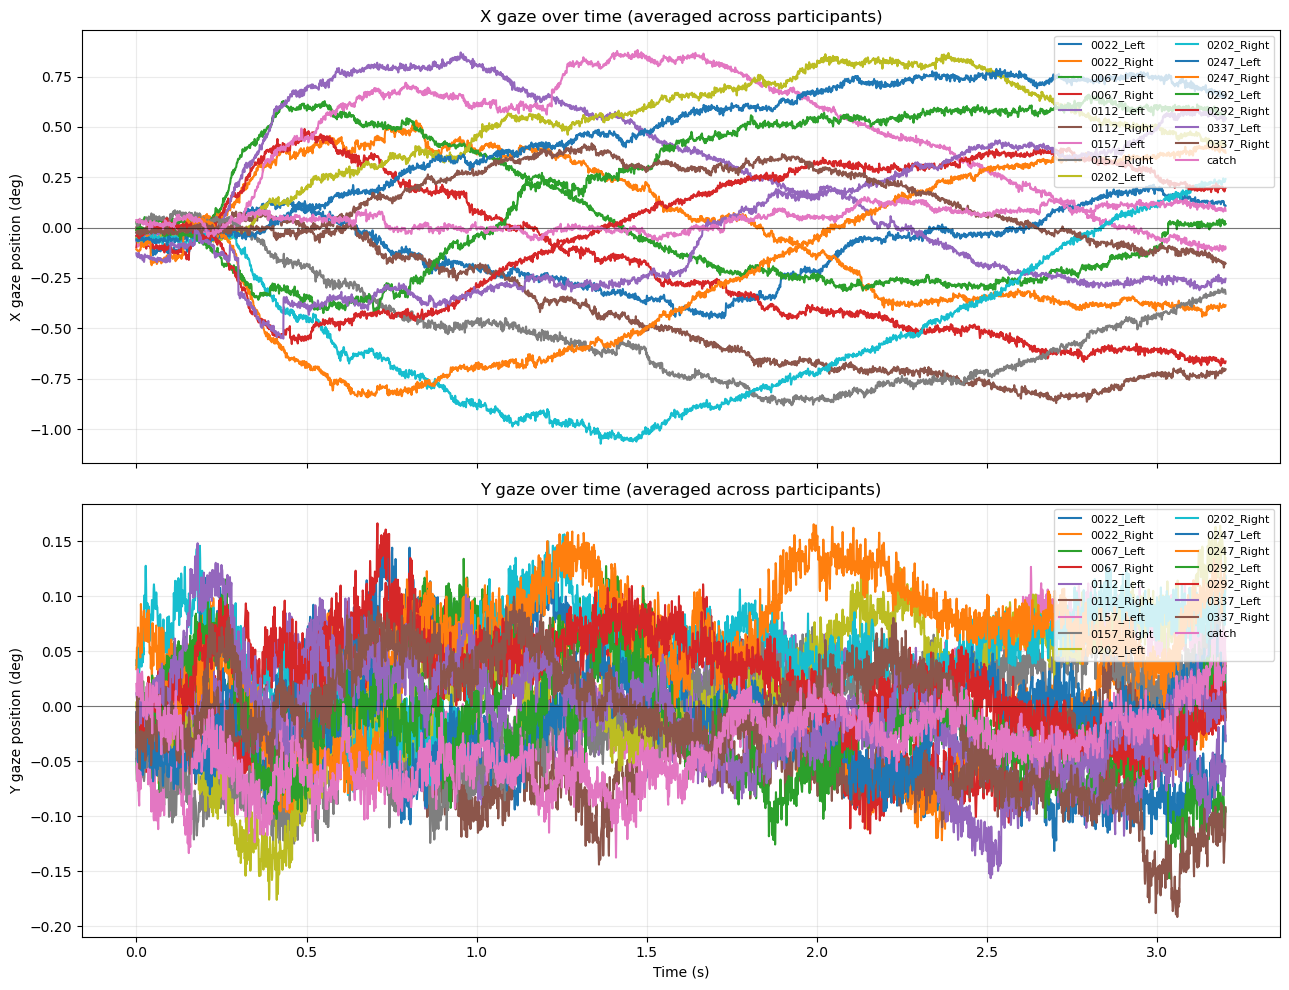

In [5]:
if timecourse_df.empty:
    raise RuntimeError('No timecourse data available.')

# Average across participants for each condition at each movie timepoint
grand_tc = (
    timecourse_df.groupby(['condition', 'time_s'])[['x_deg', 'y_deg']]
    .mean()
    .reset_index()
)

conditions = sorted(grand_tc['condition'].unique())
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

for cond in conditions:
    cur = grand_tc[grand_tc['condition'] == cond]
    axes[0].plot(cur['time_s'], cur['x_deg'], label=cond)
    axes[1].plot(cur['time_s'], cur['y_deg'], label=cond)

axes[0].set_ylabel('X gaze position (deg)')
axes[0].set_title('X gaze over time (averaged across participants)')
axes[0].axhline(0, color='k', linewidth=0.8, alpha=0.5)

axes[1].set_ylabel('Y gaze position (deg)')
axes[1].set_title('Y gaze over time (averaged across participants)')
axes[1].set_xlabel('Time (s)')
axes[1].axhline(0, color='k', linewidth=0.8, alpha=0.5)

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
#Save outputs
out_dir = Path.cwd()
overall.to_csv(out_dir / 'dynamic_overall_condition_gaze_means.csv', index=False)
grand_tc.to_csv(out_dir / 'dynamic_condition_gaze_timecourse_groupmean.csv', index=False)
print('Saved CSVs to', out_dir)